# FX Pairs: Model-Based Temporal Features

**Chapter 9: Time Series Analysis**

This notebook fits temporal models inside walk-forward folds and extracts
features for the FX Pairs case study. A spot rate moves close to a random walk
around a drift that changes slowly, which is the structure a local linear trend
state-space model is built to separate into level, slope and observation noise.

**Learning Objectives**:
- Fit a local linear trend Kalman filter per pair with MLE noise estimation
- Detect USD volatility regimes via HMM on aggregate currency returns
- Extract ARIMA residuals as short-horizon surprise features
- Maintain walk-forward discipline using the canonical train/validation folds

**Book Reference**: Chapter 9, Sections 9.2 (Kalman), 9.5 (HMM), 9.3 (ARIMA)

**Prerequisites**: FX 4H price bars, which section 1 aggregates to sessions, and
[`02_labels`](02_labels.ipynb), which writes the label parquet read in section 2 and
whose date index the folds are derived from.

**Output Contract**:
- `features/model_based.parquet` -- Temporal features aligned with Ch8
- Keys: `timestamp`, `symbol`, `fold` (fold is metadata, not a feature)
- All features use filtered (not smoothed) estimates
- Each fold contains train+validation features (downstream models select per fold)

In [1]:
"""FX Pairs: Temporal Features."""

import logging
import re
import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from hmmlearn.hmm import GaussianHMM
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from plotly.subplots import make_subplots
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA

from data import load_fx_pairs
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)

In [2]:
CASE_STUDY_ID = "fx_pairs"
# Use 0 for all symbols/folds. Test mode uses 3 symbols and 2 folds.
MAX_SYMBOLS = 0
MAX_FOLDS = 0
# Test mode uses 50 iterations and 3 HMM restarts.
KALMAN_MAXITER = 300
START_DATE = "2011-01-01"
N_HMM_RESTARTS = 10
HMM_N_STATES = 2  # low-volatility vs high-volatility USD regime
# A restart is rejected when its final EM step falls by more than this fraction of
# the log-likelihood's own magnitude. Real divergence moves hundreds of nats; the
# noise this has to tolerate is single digits against a likelihood of ~4.3e4.
HMM_STABILITY_REL_TOL = 1e-3

The session calendar is read from `setup.yaml` rather than named here. It is the
calendar that implements the 5PM rollover, so it decides which session a four-hour
bar belongs to, and `02_labels` reads the same key. A copy typed here would let this
notebook aggregate onto a different session grid than the labels were built on, and
the resulting join would simply lose rows.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

ARIMA_ORDER = (1, 0, 1)
# A Spearman IC over fewer pairs than this is a rank correlation over a handful of
# points; dates below the floor are dropped from the series rather than averaged in.
MIN_PAIRS_PER_DATE = 8

SETUP = load_setup_config(CASE_STUDY_ID)
SESSION_CALENDAR = SETUP["decision"]["session_calendar"]

## 1. Load Data and CV Config

In [4]:
# Aggregate 4H bars to sessions on the configured session calendar
fx_4h = load_fx_pairs(
    frequency="4h",
    start_date=START_DATE,
).select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])

cal = TradingCalendar(SESSION_CALENDAR)
sessions = cal.get_sessions(pd.DatetimeIndex(fx_4h["timestamp"].to_pandas()))
# Retain the original 4H timestamp as `bar_ts` so OHLC sort_by inside agg
# is order-safe (polars group_by does not contractually preserve row order).
fx_4h = (
    fx_4h.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)
prices = (
    fx_4h.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort(["symbol", "timestamp"])
)

### Select the Universe

The universe is the one declared in `setup.yaml`. The labels were built for that
list, so a pair present in the price file but absent from the declared universe
would enter the USD factor and the cross-sectional IC here while appearing in no
downstream join.

In [5]:
SYMBOLS = sorted(SETUP["universe"]["symbols"])
assert len(SYMBOLS) == SETUP["universe"]["n_assets"], (
    f"setup.yaml declares {SETUP['universe']['n_assets']} assets, "
    f"universe.symbols lists {len(SYMBOLS)}"
)
_loaded = set(prices["symbol"].unique().to_list())
assert set(SYMBOLS) <= _loaded, f"price file is missing {sorted(set(SYMBOLS) - _loaded)}"
prices = prices.filter(pl.col("symbol").is_in(SYMBOLS))
if MAX_SYMBOLS:
    SYMBOLS = SYMBOLS[:MAX_SYMBOLS]
    prices = prices.filter(pl.col("symbol").is_in(SYMBOLS))
n_symbols = len(SYMBOLS)
dates = prices.filter(pl.col("symbol") == SYMBOLS[0])["timestamp"].sort().to_list()

print(f"Loaded: {n_symbols} pairs, {len(dates)} dates")
print(f"Period: {dates[0]} to {dates[-1]}")

Loaded: 20 pairs, 3874 dates
Period: 2011-01-03 to 2025-12-31


## 2. Resolve the Walk-Forward Folds Before Anything Is Fitted

The boundaries come from `generate_cv_splits` reading the label frame and the
window in `setup.yaml`. This is the same route the downstream loader takes, so
a `fold` id in this artifact selects the same window there as it does here.

Deriving the folds here rather than replaying a stored splits file is what makes
that true. A stored array cannot track a changed calendar or a changed label
buffer, and the `fold` id is only an id: nothing downstream would report that the
window it selects is not the one the features were fitted on.

In [6]:
all_dates = sorted(prices["timestamp"].unique().to_list())

# The label is the case study's configured primary, not a name typed here: the same
# key picks the label file, the buffer that spaces the folds, and the HAC lag below.
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
# Consecutive daily decisions share (h - 1) days of outcome window, which is what the
# Newey-West lag has to cover. Read from the buffer rather than typed, so a case study
# that moves to a longer label cannot leave a stale lag behind.
LABEL_HORIZON_SESSIONS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))
# One holdout boundary, resolved once. The fold-contract rule below and the seal
# assertion in section 8 have to be the same date or the figure stops describing
# the check.
HOLDOUT_START = pd.Timestamp(load_evaluation_config(CASE_STUDY_ID)["holdout_start"]).date()
print(
    f"Primary label {PRIMARY_LABEL}, buffer {LABEL_BUFFER} -> HAC lag horizon "
    f"{LABEL_HORIZON_SESSIONS}; holdout opens {HOLDOUT_START}"
)

label_frame = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
raw_folds = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)
folds = []
for split in raw_folds:
    fold = {
        "fold": int(split["fold"]),
        "train_start": pd.Timestamp(split["train_start"]).date(),
        "train_end": pd.Timestamp(split["train_end"]).date(),
        "val_start": pd.Timestamp(split["val_start"]).date(),
        "val_end": pd.Timestamp(split["val_end"]).date(),
    }
    fold["n_train"] = sum(fold["train_start"] <= d <= fold["train_end"] for d in all_dates)
    fold["n_val"] = sum(fold["val_start"] <= d <= fold["val_end"] for d in all_dates)
    folds.append(fold)

if MAX_FOLDS:
    folds = folds[:MAX_FOLDS]

print(f"Built {len(folds)} walk-forward folds:")
for f in folds:
    print(
        f"  Fold {f['fold']}: train {f['train_start']}..{f['train_end']} "
        f"({f['n_train']} days), validation {f['val_start']}..{f['val_end']} "
        f"({f['n_val']} days)"
    )

Primary label fwd_ret_1d, buffer 1D -> HAC lag horizon 1; holdout opens 2024-01-01


Built 8 walk-forward folds:
  Fold 0: train 2018-01-04..2022-12-29 (1289 days), validation 2023-01-03..2023-12-28 (257 days)
  Fold 1: train 2017-01-04..2021-12-30 (1289 days), validation 2022-01-03..2022-12-30 (258 days)
  Fold 2: train 2016-01-05..2020-12-31 (1289 days), validation 2021-01-05..2021-12-31 (258 days)
  Fold 3: train 2015-01-05..2020-01-02 (1289 days), validation 2020-01-06..2021-01-04 (258 days)
  Fold 4: train 2014-01-03..2019-01-02 (1289 days), validation 2019-01-04..2020-01-03 (258 days)
  Fold 5: train 2013-01-03..2018-01-02 (1289 days), validation 2018-01-04..2019-01-03 (258 days)
  Fold 6: train 2012-01-04..2016-12-30 (1289 days), validation 2017-01-04..2018-01-03 (258 days)
  Fold 7: train 2011-01-04..2015-12-31 (1289 days), validation 2016-01-05..2017-01-03 (258 days)


### The Fold Contract

The figure draws what the saved artifact will contain: per fold, the window each
model's parameters are estimated on and the window they are then applied to out of
sample, with the sealed holdout shaded. Kalman noise parameters, HMM emissions and
transitions, and ARIMA coefficients are all estimated inside the blue bar of their
own row and then held frozen while the filter runs forward across the amber one.

`fx_pairs` writes features for the cross-validation folds only, so every bar stops
to the left of the rule; a downstream stage that needs a holdout vintage builds one
with `append_holdout_fold_if_needed` (`utils/modeling.py:688`). The gap between each
blue bar and its amber bar is the label buffer: those sessions update the filter
state but are written to neither split.

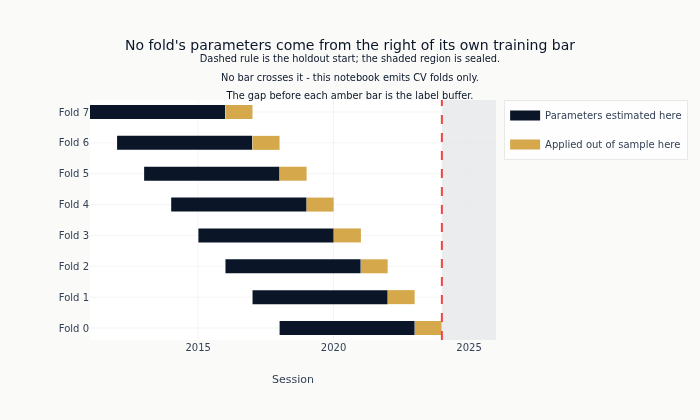

In [7]:
fig = go.Figure()
_style = {
    "Parameters estimated here": COLORS["blue"],
    "Applied out of sample here": COLORS["amber"],
}
_seen: set[str] = set()
for f in folds:
    row = f"Fold {f['fold']}"
    for kind, (start, end) in (
        ("Parameters estimated here", (f["train_start"], f["train_end"])),
        ("Applied out of sample here", (f["val_start"], f["val_end"])),
    ):
        fig.add_trace(
            go.Scatter(
                x=[start.isoformat(), end.isoformat()],
                y=[row, row],
                mode="lines",
                line={"width": 14, "color": _style[kind]},
                name=kind,
                legendgroup=kind,
                showlegend=kind not in _seen,
            )
        )
        _seen.add(kind)

fig.add_vrect(
    x0=HOLDOUT_START.isoformat(),
    x1=max(all_dates).isoformat(),
    fillcolor=COLORS["neutral"],
    opacity=0.10,
    line_width=0,
    layer="below",
)
fig.add_vline(x=HOLDOUT_START.isoformat(), line_dash="dash", line_color=COLORS["negative"])
fig.update_layout(
    title=(
        "No fold's parameters come from the right of its own training bar"
        "<br><sup>Dashed rule is the holdout start; the shaded region is sealed."
        "<br>No bar crosses it - this notebook emits CV folds only."
        "<br>The gap before each amber bar is the label buffer.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="",
    height=420,
    margin={"l": 90},
)
fig.show()

## 3. Kalman Filter (Primary)

The local linear trend model decomposes price into level + slope:

**State**: $\mathbf{x}_t = [\text{level}_t, \text{slope}_t]^\top$

**Transition**: $\mathbf{x}_t = \mathbf{F}\mathbf{x}_{t-1} + \mathbf{w}_t$

**Observation**: $y_t = [1, 0]\mathbf{x}_t + v_t$

Noise parameters $(R, Q)$ are estimated via MLE on each training window.
The filter is then applied forward through the validation period without
re-estimation. We model log prices so level, slope, innovation, and uncertainty
have comparable units across JPY and non-JPY pairs.

In [8]:
def kalman_local_linear(
    prices_arr: np.ndarray,
    observation_noise: float = 1.0,
    level_noise: float = 0.01,
    slope_noise: float = 0.001,
) -> dict[str, np.ndarray]:
    """Local linear trend Kalman filter.

    Returns dict with level, slope, innovation, uncertainty arrays.
    """
    n = len(prices_arr)
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = np.array([[level_noise, 0.0], [0.0, slope_noise]])
    R = np.array([[observation_noise]])

    x = np.array([prices_arr[0], 0.0])
    P = np.eye(2) * 10.0

    levels = np.zeros(n)
    slopes = np.zeros(n)
    innovations = np.zeros(n)
    uncertainties = np.zeros(n)
    log_lik = 0.0

    for t in range(n):
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        y = prices_arr[t] - H @ x_pred
        S = H @ P_pred @ H.T + R

        log_lik += -0.5 * (np.log(2 * np.pi * S[0, 0]) + y[0] ** 2 / S[0, 0])

        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K @ y
        P = (np.eye(2) - K @ H) @ P_pred

        levels[t] = x[0]
        slopes[t] = x[1]
        innovations[t] = y[0]
        uncertainties[t] = P[0, 0]

    return {
        "level": levels,
        "slope": slopes,
        "innovation": innovations,
        "uncertainty": uncertainties,
        "log_likelihood": log_lik,
    }

### Optimize the Kalman Noise Parameters

In [9]:
def neg_log_likelihood(params: np.ndarray, prices_arr: np.ndarray) -> float:
    """Negative log-likelihood for MLE optimization."""
    obs_noise = np.exp(params[0])
    level_noise = np.exp(params[1])
    slope_noise = np.exp(params[2])
    result = kalman_local_linear(prices_arr, obs_noise, level_noise, slope_noise)
    return -result["log_likelihood"]

The optimizer starts from the observed return variance so the noise scales
remain comparable across currency pairs.

In [10]:
def fit_kalman_mle(train_prices: np.ndarray, maxiter: int = 300) -> tuple[float, float, float]:
    """Estimate Kalman noise parameters via MLE on training data."""
    return_variance = max(float(np.var(np.diff(train_prices))), 1e-10)
    x0 = np.log([return_variance * 0.5, return_variance * 0.1, return_variance * 0.01])
    opt = minimize(
        neg_log_likelihood,
        x0,
        args=(train_prices,),
        method="Nelder-Mead",
        options={"maxiter": maxiter},
    )
    return tuple(np.exp(opt.x))

### Run Kalman Filter Walk-Forward

For each fold, we estimate noise parameters on training data, then
apply the filter forward through the full train+validation period.

**Path causality**: Fixed training parameters filter the complete path through
validation. The one-session label buffer updates the state but is not emitted as
a train or validation row. At time $t$, the update uses only observations through
$t$.

In [11]:
def extract_kalman_features(fold: dict, symbol: str) -> tuple[list[dict], dict | None]:
    """Fit one training fold and filter its train-to-validation path.

    Returns ``(rows, params)``. ``params`` carries the MLE noise estimates for this
    fold and symbol so the fit-stability section can draw what was estimated rather
    than what the emitted features happened to average to.
    """
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    sym_log_prices = np.log(sym_data["close"].to_numpy())
    train_mask = [fold["train_start"] <= d <= fold["train_end"] for d in sym_dates]
    val_mask = [fold["val_start"] <= d <= fold["val_end"] for d in sym_dates]
    path_mask = [fold["train_start"] <= d <= fold["val_end"] for d in sym_dates]
    train_prices = sym_log_prices[train_mask]
    path_prices = sym_log_prices[path_mask]
    path_dates = [d for d, include in zip(sym_dates, path_mask, strict=True) if include]
    emit_idx = [
        i for i, d in enumerate(path_dates) if d <= fold["train_end"] or d >= fold["val_start"]
    ]
    if len(train_prices) < 252 or sum(val_mask) < 10:
        return [], None
    opt_params = fit_kalman_mle(train_prices, maxiter=KALMAN_MAXITER)
    filtered = kalman_local_linear(path_prices, *opt_params)
    train_idx = np.array([d <= fold["train_end"] for d in path_dates])
    slope_mean = np.mean(filtered["slope"][train_idx])
    slope_std = np.std(filtered["slope"][train_idx]) + 1e-10
    moving_average = pl.Series(path_prices).rolling_mean(63, min_samples=1).to_numpy()
    params = {
        "fold": fold["fold"],
        "symbol": symbol,
        "observation_noise": float(opt_params[0]),
        "level_noise": float(opt_params[1]),
        "slope_noise": float(opt_params[2]),
    }
    rows = [
        {
            "timestamp": path_dates[i],
            "symbol": symbol,
            "fold": fold["fold"],
            "kalman_trend": filtered["level"][i] - moving_average[i],
            "kalman_slope": filtered["slope"][i],
            "kalman_slope_zscore": (filtered["slope"][i] - slope_mean) / slope_std,
            "kalman_innovation": filtered["innovation"][i],
            "kalman_smoothness": 1.0 / (filtered["uncertainty"][i] + 1e-10),
        }
        for i in emit_idx
    ]
    return rows, params

In [12]:
kalman_results = []
kalman_params = []
for fold in folds:
    for symbol in SYMBOLS:
        try:
            rows, params = extract_kalman_features(fold, symbol)
            kalman_results.extend(rows)
            if params is not None:
                kalman_params.append(params)
        except Exception as exc:
            raise RuntimeError(
                f"Kalman MLE failed for fold {fold['fold']}, symbol {symbol}"
            ) from exc
    if fold["fold"] % 2 == 1 or fold["fold"] == folds[-1]["fold"]:
        n_fold = sum(row["fold"] == fold["fold"] for row in kalman_results)
        print(f"  Kalman fold {fold['fold']}: {n_fold:,} features")

kalman_df = pl.DataFrame(kalman_results)
print(f"\nKalman features: {len(kalman_df):,} rows, {n_symbols} pairs x {len(folds)} folds")

  Kalman fold 1: 30,940 features


  Kalman fold 3: 30,940 features


  Kalman fold 5: 30,940 features


  Kalman fold 7: 30,940 features

Kalman features: 247,500 rows, 20 pairs x 8 folds


**The Kalman seal, executed.** Two assertions, each of which stops the notebook
rather than leaving plausible numbers behind.

Containment: every emitted row is dated inside its own fold's training or
validation window, and none reaches the holdout.

Forward filtering: `kalman_local_linear` is a recursion, so the state at index `i`
must not move when the observations after `i` are deleted. That is what separates a
filter from a smoother, and it is invisible in the emitted numbers.

In [13]:
for fold in folds:
    rows = kalman_df.filter(pl.col("fold") == fold["fold"])
    if len(rows) == 0:
        continue
    assert rows["timestamp"].min() >= fold["train_start"], (
        f"fold {fold['fold']}: Kalman row before its own train_start"
    )
    assert rows["timestamp"].max() <= fold["val_end"], (
        f"fold {fold['fold']}: Kalman row after its own val_end"
    )
assert kalman_df["timestamp"].max() < HOLDOUT_START, "Kalman emitted a holdout-dated row"

seal_prices = np.log(
    prices.filter(pl.col("symbol") == SYMBOLS[0]).sort("timestamp")["close"].to_numpy()
)
cut = len(seal_prices) // 2
full_run = kalman_local_linear(seal_prices)
prefix_run = kalman_local_linear(seal_prices[:cut])
kalman_drift = max(
    float(np.abs(full_run[k][:cut] - prefix_run[k]).max()) for k in ("level", "slope", "innovation")
)
assert kalman_drift < 1e-10, f"Kalman state moved by {kalman_drift:.2e} - not a forward filter"
print(
    f"Kalman seal holds across {len(folds)} folds; last emitted date "
    f"{kalman_df['timestamp'].max()} < holdout start {HOLDOUT_START}; deleting the last "
    f"{len(seal_prices) - cut} observations of {SYMBOLS[0]} moves the first {cut} filtered "
    f"states by {kalman_drift:.2e}"
)

Kalman seal holds across 8 folds; last emitted date 2023-12-28 < holdout start 2024-01-01; deleting the last 1937 observations of AUD_JPY moves the first 1937 filtered states by 0.00e+00


## 4. HMM Regimes (Secondary)

We fit a 2-state Gaussian HMM on aggregate USD returns to detect
low- and high-volatility regimes. The HMM is fitted on each training window,
and filtered (not smoothed) probabilities are extracted for the full
train+validation period of each fold. Variance alone does not identify a
risk-off state, so the feature uses the narrower high-volatility label.

The aggregate USD return series is a dollar-index proxy: every pair in the universe
quoted against USD, signed by which side of the quote the dollar sits on. The two
sides are derived from the declared universe rather than listed, so a universe change
cannot drop a leg of the factor without the list changing with it.

In [14]:
USD_LONG = [s for s in SYMBOLS if s.startswith("USD_")]
USD_SHORT = [s for s in SYMBOLS if s.endswith("_USD")]
print(f"USD factor legs: long {USD_LONG}, short {USD_SHORT}")

daily_rets = prices.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("ret")
).drop_nulls(subset=["ret"])

usd_rets = daily_rets.filter(pl.col("symbol").is_in(USD_LONG + USD_SHORT)).with_columns(
    pl.when(pl.col("symbol").is_in(USD_LONG))
    .then(pl.col("ret"))
    .otherwise(-pl.col("ret"))
    .alias("usd_ret")
)

usd_daily = (
    usd_rets.group_by("timestamp")
    .agg(
        pl.col("usd_ret").mean().alias("usd_ret"),
        pl.col("usd_ret").std().alias("usd_vol"),
    )
    .sort("timestamp")
)

# Rolling volatility for HMM input
usd_daily = usd_daily.with_columns(pl.col("usd_ret").rolling_std(21).alias("usd_vol_21d"))

print(f"USD factor series: {len(usd_daily):,} dates")

USD factor legs: long ['USD_CAD', 'USD_CHF', 'USD_JPY'], short ['AUD_USD', 'EUR_USD', 'GBP_USD', 'NZD_USD']
USD factor series: 3,873 dates


In [15]:
def compute_filtered_probs_manual(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm. Returns probabilities, not smoothed posteriors.
    """
    framelogprob = model._compute_log_likelihood(X)
    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    fwdlattice = np.zeros((n_samples, n_components))
    fwdlattice[0] = log_startprob + framelogprob[0]

    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    filtered = np.exp(fwdlattice - log_normalizer)
    return filtered

Multiple deterministic restarts reduce sensitivity to local likelihood maxima.
Fits whose final likelihood step decreases are excluded rather than silently used.

In [16]:
def fit_best_hmm(X_train: np.ndarray) -> tuple[GaussianHMM, float, int]:
    """Return the best stable training-only HMM fit."""
    best_ll = -np.inf
    best_model = None
    unstable = 0
    for seed in range(N_HMM_RESTARTS):
        try:
            model = GaussianHMM(
                n_components=HMM_N_STATES,
                covariance_type="full",
                n_iter=100,
                random_state=seed,
                tol=1e-4,
            ).fit(X_train)
            history = list(model.monitor_.history)
            final_delta = history[-1] - history[-2] if len(history) >= 2 else 0.0
            # Relative to the likelihood being stepped on: an absolute nat threshold
            # rejects ordinary floating-point chatter at the optimum, which on a
            # likelihood of this magnitude discards every restart.
            scale = max(abs(history[-2]) if len(history) >= 2 else 1.0, 1.0)
            if final_delta < -HMM_STABILITY_REL_TOL * scale:
                unstable += 1
                continue
            score = model.score(X_train)
            if np.isfinite(score) and score > best_ll:
                best_ll, best_model = score, model
        except Exception:
            continue
    if best_model is None:
        raise RuntimeError("No stable HMM fit")
    return best_model, best_ll, unstable

Each fold emits only training and validation dates. The configured buffer updates
the forward state but is not written to either split.

In [17]:
def extract_hmm_features(fold: dict) -> tuple[list[dict], GaussianHMM, np.ndarray, float, int]:
    """Fit one HMM fold and return its filtered feature rows."""
    train_idx = [
        i for i, d in enumerate(valid_dates) if fold["train_start"] <= d <= fold["train_end"]
    ]
    val_idx = [i for i, d in enumerate(valid_dates) if fold["val_start"] <= d <= fold["val_end"]]
    path_idx = [i for i, d in enumerate(valid_dates) if fold["train_start"] <= d <= fold["val_end"]]
    if len(train_idx) < 252 or len(val_idx) < 10:
        raise ValueError(f"Insufficient HMM data for fold {fold['fold']}")
    model, score, unstable = fit_best_hmm(usd_arr[train_idx])
    order = np.argsort([np.trace(covariance) for covariance in model.covars_])
    filtered = compute_filtered_probs_manual(model, usd_arr[path_idx])
    path_dates = [valid_dates[i] for i in path_idx]
    rows = [
        {
            "timestamp": hmm_date,
            "fold": fold["fold"],
            "hmm_regime_prob_high_vol": float(filtered[i, order[1]]),
            "hmm_regime_transition_5d": float(
                filtered[i, order[1]] - filtered[i - 5, order[1]] if i >= 5 else 0.0
            ),
        }
        for i, hmm_date in enumerate(path_dates)
        if hmm_date <= fold["train_end"] or hmm_date >= fold["val_start"]
    ]
    return rows, model, order, score, unstable

The HMM observations are expressed in **percent**, not in native decimal returns,
because `GaussianHMM` carries two additive covariance regularizers whose defaults are
sized for data of order one, and neither of them scales with the series it is given.

- `min_covar` is added to the diagonal of the **initial** covariance
  (`hmmlearn/hmm.py`, `_init`: `cv = np.cov(X.T) + self.min_covar * np.eye(...)`). It is
  in the same units as a variance, and it is not a floor on the fitted covariance, so
  what it sets is where EM starts.
- `covars_prior`, with `covars_weight=1`, acts at every M-step (`_do_mstep`, the `full`
  branch this notebook fits: `covars = (covars_prior + c_n) / c_d`). Here `c_n` is the
  posterior-weighted **sum** of squared deviations over the observations assigned to a
  state and `c_d` is that state's posterior count, so dividing through leaves
  approximately `variance + covars_prior / c_d`. The prior adds a fixed amount to each
  state's variance estimate, and how far it moves that estimate depends on how many
  observations the state holds.

Scaling by 100 multiplies the variance by 10,000 and moves it into the range those two
defaults were chosen for. The cell below measures both effects against the series they
act on rather than asserting them.

In [18]:
HMM_SCALE = 100.0  # decimal returns -> percent, so the fixed regularizers stay small
HMM_MIN_COVAR = GaussianHMM().min_covar  # added to the initial covariance
HMM_COVARS_PRIOR = GaussianHMM().covars_prior  # additive term in the M-step numerator

valid_usd = usd_daily.drop_nulls(subset=["usd_ret", "usd_vol_21d"])
valid_dates = valid_usd["timestamp"].to_list()
_native = valid_usd.select(["usd_ret", "usd_vol_21d"]).to_numpy()
usd_arr = _native * HMM_SCALE

Both comparisons are against the variance of the return column the HMM actually sees.
`c_d` is a state's posterior count, so splitting the fitted observations evenly across
the states gives its order of magnitude without refitting anything.

In [19]:
native_var = float(_native[:, 0].var())
scaled_var = float(usd_arr[:, 0].var())
obs_per_state = len(_native) / HMM_N_STATES
prior_term = HMM_COVARS_PRIOR / obs_per_state

print(f"USD return variance          native {native_var:.3e}   scaled {scaled_var:.3e}")
print(f"Observations per state, approx.    {obs_per_state:,.0f}")
print("\nInitialisation, min_covar added straight to the covariance:")
print(
    f"  min_covar {HMM_MIN_COVAR:.1e} / variance   native {HMM_MIN_COVAR / native_var:9.1f}x"
    f"   scaled {HMM_MIN_COVAR / scaled_var:.4f}x"
)
print("\nFitting, covars_prior / c_d added to each state's variance estimate:")
print(
    f"  prior term {prior_term:.2e}          native inflates "
    f"{1 + prior_term / native_var:.3f}x   scaled inflates {1 + prior_term / scaled_var:.3f}x"
)

USD return variance          native 1.802e-05   scaled 1.802e-01
Observations per state, approx.    1,926

Initialisation, min_covar added straight to the covariance:
  min_covar 1.0e-03 / variance   native      55.5x   scaled 0.0055x

Fitting, covars_prior / c_d added to each state's variance estimate:
  prior term 5.19e-06          native inflates 1.288x   scaled inflates 1.000x


Each fold is fitted on its own training window, and the loop keeps the restart count it
had to discard.

In [20]:
hmm_results = []
hmm_params = []
unstable_hmm_fits = 0
best_model = None
for fold in folds:
    rows, best_model, order, best_ll, unstable = extract_hmm_features(fold)
    hmm_results.extend(rows)
    unstable_hmm_fits += unstable
    _trans = best_model.transmat_[np.ix_(order, order)]
    hmm_params.append(
        {
            "fold": fold["fold"],
            "persist_low_vol": float(_trans[0, 0]),
            "persist_high_vol": float(_trans[1, 1]),
            "log_likelihood": float(best_ll),
        }
    )
    print(f"  HMM fold {fold['fold']}: {len(rows)} dates (train+validation), best LL={best_ll:.1f}")
print(f"HMM unstable restarts excluded: {unstable_hmm_fits}")

  HMM fold 0: 1546 dates (train+validation), best LL=843.5


  HMM fold 1: 1547 dates (train+validation), best LL=1145.6


  HMM fold 2: 1547 dates (train+validation), best LL=934.2


  HMM fold 3: 1547 dates (train+validation), best LL=962.5


  HMM fold 4: 1547 dates (train+validation), best LL=837.5


  HMM fold 5: 1547 dates (train+validation), best LL=807.7


  HMM fold 6: 1547 dates (train+validation), best LL=761.1


  HMM fold 7: 1527 dates (train+validation), best LL=567.7
HMM unstable restarts excluded: 0


`best_model` and `order` are what the fold loop finished on, which is `folds[-1]`:
fold 0 covers the most recent validation year, so the matrix below is the one fitted
on the oldest training window. Each row is the state the session starts in and each column
the probability of the next session's state, so the diagonal is persistence and the
expected run length of a state is $1/(1-p)$.

In [21]:
trans = best_model.transmat_[np.ix_(order, order)]
transition_table = pl.DataFrame(
    {
        "from_state": ["low_vol", "high_vol"],
        "to_low_vol": [trans[0, 0], trans[1, 0]],
        "to_high_vol": [trans[0, 1], trans[1, 1]],
        "expected_sessions": [1.0 / (1.0 - trans[0, 0]), 1.0 / (1.0 - trans[1, 1])],
    }
)
print(f"HMM transition matrix, fold {folds[-1]['fold']}, states ordered by variance:")
transition_table

HMM transition matrix, fold 7, states ordered by variance:


from_state,to_low_vol,to_high_vol,expected_sessions
str,f64,f64,f64
"""low_vol""",0.987391,0.012609,79.31121
"""high_vol""",0.013586,0.986414,73.604467


In [22]:
hmm_df = pl.DataFrame(hmm_results)
print(f"HMM features: {len(hmm_df):,} rows")

HMM features: 12,355 rows


**The HMM seal, executed.** Same two checks as the Kalman section, against the
quantity this section emits. `compute_filtered_probs_manual` implements the forward
recursion by hand, so the truncation test is the only thing standing between it and
a smoothed posterior, which would carry the whole validation window into every
training-date feature.

In [23]:
for fold in folds:
    rows = hmm_df.filter(pl.col("fold") == fold["fold"])
    if len(rows) == 0:
        continue
    assert rows["timestamp"].min() >= fold["train_start"], (
        f"fold {fold['fold']}: HMM row before its own train_start"
    )
    assert rows["timestamp"].max() <= fold["val_end"], (
        f"fold {fold['fold']}: HMM row after its own val_end"
    )
assert hmm_df["timestamp"].max() < HOLDOUT_START, "HMM emitted a holdout-dated row"

seal_train_idx = [
    i for i, d in enumerate(valid_dates) if folds[0]["train_start"] <= d <= folds[0]["train_end"]
]
seal_model, _, _ = fit_best_hmm(usd_arr[seal_train_idx])
seal_obs = usd_arr[seal_train_idx]
cut = len(seal_obs) // 2
hmm_drift = float(
    np.abs(
        compute_filtered_probs_manual(seal_model, seal_obs)[:cut]
        - compute_filtered_probs_manual(seal_model, seal_obs[:cut])
    ).max()
)
assert hmm_drift < 1e-10, f"filtered probabilities moved by {hmm_drift:.2e} - not filtered"
print(
    f"HMM seal holds across {len(folds)} folds; last emitted date {hmm_df['timestamp'].max()} "
    f"< holdout start {HOLDOUT_START}; deleting the last {len(seal_obs) - cut} observations "
    f"of fold {folds[0]['fold']} moves the first {cut} filtered probabilities by {hmm_drift:.2e}"
)

HMM seal holds across 8 folds; last emitted date 2023-12-28 < holdout start 2024-01-01; deleting the last 645 observations of fold 0 moves the first 644 filtered probabilities by 0.00e+00


### Fit Stability Across Folds

The training windows roll forward one year at a time and overlap heavily, so the
fitted parameters should move slowly. A parameter that is identical across folds
says per-fold refitting bought nothing; one that swings is a warning about the
feature that depends on it.

The left panel is the Kalman MLE noise decomposition: the median across pairs of the
estimated observation, level and slope variances, on a log axis because the three
span orders of magnitude by construction.

**Read the observation-noise line before the others.** In most folds it sits near the
level noise, which is the decomposition the model is meant to make. In some folds it
drops by ten orders of magnitude, to a number that is zero for every practical
purpose. That is the Nelder-Mead search running the likelihood off the end
of its own parameter: with `R` at zero the filter believes each observed price
exactly, the level becomes the price, the innovation becomes zero, and
`kalman_smoothness`, which is one over the state variance, goes as large as the
floating-point floor allows. Those folds emit features on a different scale from the
rest, and this is the figure that shows it. It is a limitation of the fit and not of
the seal: nothing about it reaches across a fold boundary.

The right panel is the HMM's two self-transition probabilities. Drawn as
probabilities they are four traces within a hundredth of one another and of the top
of the axis, so they are drawn as the expected run length each one implies,
$1/(1-p_{\text{stay}})$ - the same quantity `hmm_regime_transition_5d` depends on.

Refitting the ARIMA per pair produces AR and MA coefficients with no market-level
counterpart, so it has no line here.

In [24]:
kalman_param_df = pl.DataFrame(kalman_params)
kalman_param_summary = (
    kalman_param_df.group_by("fold")
    .agg(
        pl.col("observation_noise").median().alias("observation_noise"),
        pl.col("level_noise").median().alias("level_noise"),
        pl.col("slope_noise").median().alias("slope_noise"),
        pl.len().alias("n_pairs"),
    )
    .sort("fold")
)
hmm_param_df = pl.DataFrame(hmm_params).sort("fold")

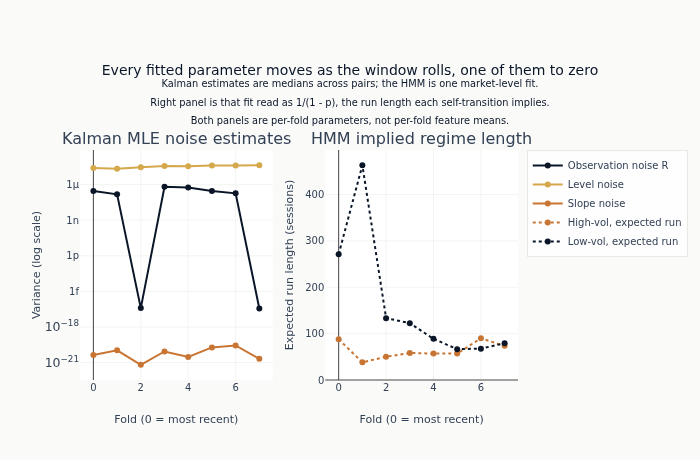

In [25]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Kalman MLE noise estimates", "HMM implied regime length"],
    horizontal_spacing=0.12,
)
for column, name, color in (
    ("observation_noise", "Observation noise R", COLORS["blue"]),
    ("level_noise", "Level noise", COLORS["amber"]),
    ("slope_noise", "Slope noise", COLORS["copper"]),
):
    fig.add_trace(
        go.Scatter(
            x=kalman_param_summary["fold"].to_list(),
            y=kalman_param_summary[column].to_list(),
            mode="lines+markers",
            name=name,
            line={"color": color},
        ),
        row=1,
        col=1,
    )
for column, name, color in (
    ("persist_high_vol", "High-vol, expected run", COLORS["copper"]),
    ("persist_low_vol", "Low-vol, expected run", COLORS["blue"]),
):
    fig.add_trace(
        go.Scatter(
            x=hmm_param_df["fold"].to_list(),
            y=(1.0 / (1.0 - hmm_param_df[column])).to_list(),
            mode="lines+markers",
            name=name,
            line={"color": color, "dash": "dot"},
        ),
        row=1,
        col=2,
    )
fig.update_yaxes(title_text="Variance (log scale)", type="log", row=1, col=1)
fig.update_yaxes(title_text="Expected run length (sessions)", rangemode="tozero", row=1, col=2)
fig.update_xaxes(title_text="Fold (0 = most recent)", row=1, col=1)
fig.update_xaxes(title_text="Fold (0 = most recent)", row=1, col=2)
fig.update_layout(
    title=(
        "Every fitted parameter moves as the window rolls, one of them to zero"
        "<br><sup>Kalman estimates are medians across pairs; the HMM is one "
        "market-level fit."
        "<br>Right panel is that fit read as 1/(1 - p), the run length each "
        "self-transition implies."
        "<br>Both panels are per-fold parameters, not per-fold feature means.</sup>"
    ),
    height=460,
    margin={"t": 150},
)
fig.show()

## 5. ARIMA Residuals (Secondary)

ARIMA(1,0,1) on daily returns per pair. The residual (innovation) captures
short-horizon autocorrelation that the filter removes.

**`fit.apply()` semantics**: after fitting ARIMA on training returns,
`fit.apply(path_rets, refit=False)` re-filters the longer path with the *fixed* AR
and MA coefficients from that training window. The state recursion advances with
each new observation; the coefficients do not move, and the seal below checks that
element by element.

In [26]:
def extract_arima_features(fold: dict, symbol: str) -> list[dict]:
    """Fit one training fold and refilter its train-to-validation return path."""
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    sym_close = sym_data["close"].to_numpy()
    sym_rets = np.diff(sym_close) / sym_close[:-1]
    ret_dates = sym_dates[1:]
    train_mask = [fold["train_start"] <= d <= fold["train_end"] for d in ret_dates]
    val_mask = [fold["val_start"] <= d <= fold["val_end"] for d in ret_dates]
    path_mask = [fold["train_start"] <= d <= fold["val_end"] for d in ret_dates]
    train_rets = sym_rets[train_mask]
    path_rets = sym_rets[path_mask]
    path_dates = [d for d, include in zip(ret_dates, path_mask, strict=True) if include]
    if len(train_rets) < 252 or sum(val_mask) < 10:
        return []
    fit = ARIMA(train_rets, order=ARIMA_ORDER).fit()
    train_resid_std = np.std(fit.resid) + 1e-10
    extended = fit.apply(path_rets, refit=False)
    predicted = extended.predict(start=0, end=len(path_rets) - 1)
    return [
        {
            "timestamp": arima_date,
            "symbol": symbol,
            "fold": fold["fold"],
            "arima_forecast": float(predicted[i]),
            "arima_residual": float(path_rets[i] - predicted[i]),
            "arima_residual_zscore": float((path_rets[i] - predicted[i]) / train_resid_std),
        }
        for i, arima_date in enumerate(path_dates)
        if arima_date <= fold["train_end"] or arima_date >= fold["val_start"]
    ]

In [27]:
arima_results = []
for fold in folds:
    for symbol in SYMBOLS:
        try:
            arima_results.extend(extract_arima_features(fold, symbol))
        except Exception as exc:
            raise RuntimeError(
                f"ARIMA fit failed for fold {fold['fold']}, symbol {symbol}"
            ) from exc
    if fold["fold"] % 2 == 0 or fold["fold"] == folds[-1]["fold"]:
        n_fold = sum(row["fold"] == fold["fold"] for row in arima_results)
        print(f"  ARIMA fold {fold['fold']}: {n_fold:,} features")

arima_df = pl.DataFrame(arima_results)
print(f"\nARIMA features: {len(arima_df):,} rows")

  ARIMA fold 0: 30,920 features


  ARIMA fold 2: 30,940 features


  ARIMA fold 4: 30,940 features


  ARIMA fold 6: 30,940 features


  ARIMA fold 7: 30,940 features

ARIMA features: 247,500 rows


**The ARIMA seal, executed.** The claim this section rests on is the one about
`fit.apply(..., refit=False)`: the AR and MA coefficients come from the training
window and the call re-filters without re-estimating. Containment is checked against
the emitted frame, and the no-re-estimation claim is checked by comparing the
applied model's parameters against the training fit's, element by element.

In [28]:
for fold in folds:
    rows = arima_df.filter(pl.col("fold") == fold["fold"])
    if len(rows) == 0:
        continue
    assert rows["timestamp"].min() >= fold["train_start"], (
        f"fold {fold['fold']}: ARIMA row before its own train_start"
    )
    assert rows["timestamp"].max() <= fold["val_end"], (
        f"fold {fold['fold']}: ARIMA row after its own val_end"
    )
assert arima_df["timestamp"].max() < HOLDOUT_START, "ARIMA emitted a holdout-dated row"

seal_data = prices.filter(pl.col("symbol") == SYMBOLS[0]).sort("timestamp")
seal_close = seal_data["close"].to_numpy()
seal_rets = np.diff(seal_close) / seal_close[:-1]
seal_ret_dates = seal_data["timestamp"].to_list()[1:]
seal_fold = folds[0]
seal_train = seal_rets[
    [seal_fold["train_start"] <= d <= seal_fold["train_end"] for d in seal_ret_dates]
]
seal_path = seal_rets[
    [seal_fold["train_start"] <= d <= seal_fold["val_end"] for d in seal_ret_dates]
]
seal_fit = ARIMA(seal_train, order=ARIMA_ORDER).fit()
seal_applied = seal_fit.apply(seal_path, refit=False)
param_drift = float(np.abs(np.asarray(seal_fit.params) - np.asarray(seal_applied.params)).max())
assert param_drift == 0.0, f"apply() re-estimated: parameters moved by {param_drift:.2e}"
print(
    f"ARIMA seal holds across {len(folds)} folds; last emitted date "
    f"{arima_df['timestamp'].max()} < holdout start {HOLDOUT_START}; extending "
    f"{SYMBOLS[0]} fold {seal_fold['fold']} from {len(seal_train)} to {len(seal_path)} "
    f"observations moves the fitted parameters by {param_drift:.2e}"
)

ARIMA seal holds across 8 folds; last emitted date 2023-12-28 < holdout start 2024-01-01; extending AUD_JPY fold 0 from 1289 to 1547 observations moves the fitted parameters by 0.00e+00


## 6. Merge Temporal Features

Combine Kalman, HMM, and ARIMA features into a single DataFrame.
The `fold` column is preserved as metadata -- downstream models use it
to select the correct train+validation features for each walk-forward fold.

In [29]:
# Start with Kalman (per symbol, per date, per fold)
temporal_df = kalman_df.sort(["symbol", "timestamp", "fold"])

# Add HMM features (broadcast across symbols -- market-level, per fold)
if len(hmm_df) > 0:
    temporal_df = temporal_df.join(hmm_df, on=["timestamp", "fold"], how="left", validate="m:1")

# Add ARIMA features (per symbol, per date, per fold)
if len(arima_df) > 0:
    temporal_df = temporal_df.join(
        arima_df, on=["symbol", "timestamp", "fold"], how="left", validate="1:1"
    )

temporal_df = temporal_df.sort(["symbol", "timestamp", "fold"])

# List temporal feature columns (fold is metadata, not a feature)
temporal_feature_cols = [c for c in temporal_df.columns if c not in {"timestamp", "symbol", "fold"}]
duplicate_keys = temporal_df.select(
    pl.struct("timestamp", "symbol", "fold").is_duplicated().sum()
).item()
assert duplicate_keys == 0, f"Duplicate temporal keys: {duplicate_keys}"

print(
    f"\nMerged temporal features: {len(temporal_df):,} rows, {len(temporal_feature_cols)} features"
)
print(f"Features: {temporal_feature_cols}")


Merged temporal features: 247,500 rows, 10 features
Features: ['kalman_trend', 'kalman_slope', 'kalman_slope_zscore', 'kalman_innovation', 'kalman_smoothness', 'hmm_regime_prob_high_vol', 'hmm_regime_transition_5d', 'arima_forecast', 'arima_residual', 'arima_residual_zscore']


## 7. Save Temporal Features

In [30]:
output_path = FEATURES_DIR / "model_based.parquet"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal_df.write_parquet(output_path)
print(f"Saved: {output_path.relative_to(CASE_DIR)}")
print(f"  Shape: {temporal_df.shape}")

Saved: features/model_based.parquet
  Shape: (247500, 13)


## 8. Incremental Evaluation

The screen asks one question of each emitted feature: on rows no model in this
notebook was fitted on, does its cross-sectional rank correlation with the next
session's return differ from zero? Only each fold's validation rows enter. A
training-row feature is a valid input to a downstream fit, but it is not
out-of-sample evidence about the feature itself.

`05_evaluation` joins these features with the Chapter 8 financial set and measures
what they add to it; that comparison needs both feature files and is made there.

In [31]:
validation_frames = [
    temporal_df.filter(
        (pl.col("fold") == fold["fold"])
        & pl.col("timestamp").is_between(fold["val_start"], fold["val_end"], closed="both")
    )
    for fold in folds
]
eval_features = pl.concat(validation_frames).sort(["timestamp", "symbol"])
eval_duplicates = eval_features.select(
    pl.struct("timestamp", "symbol").is_duplicated().sum()
).item()
assert eval_duplicates == 0, f"Overlapping validation features: {eval_duplicates}"

label_col = [c for c in label_frame.columns if c not in {"timestamp", "symbol"}][0]
label_endpoints = label_frame.sort(["symbol", "timestamp"]).with_columns(
    pl.col("timestamp").shift(-1).over("symbol").alias("_label_end")
)
eval_df = eval_features.join(label_endpoints, on=["timestamp", "symbol"], how="inner")
assert eval_df["_label_end"].max() < HOLDOUT_START, (
    "A validation decision resolves its label inside the holdout window"
)
print(
    f"Out-of-sample eval set: {len(eval_df):,} rows, "
    f"{eval_df['timestamp'].n_unique():,} dates, label: {label_col}"
)

Out-of-sample eval set: 41,260 rows, 2,063 dates, label: fwd_ret_1d


`cross_sectional_ic_series` builds the per-date series and sorts it on the date
column, which is what the Newey-West correction below then reads as time order. A
date with fewer than `MIN_PAIRS_PER_DATE` usable pairs returns a **null** IC. A date
on which the feature is constant across the cross-section returns a **NaN** instead,
because the rank correlation is undefined rather than unavailable - and for the two
market-level HMM columns that is every date.

Both have to be dropped, and dropping only the nulls is not a smaller mistake than
dropping neither. A NaN that reaches the next cell becomes a NaN mean IC, a NaN p-value, and
then a NaN for **every** feature's Benjamini-Hochberg adjusted p-value, because the
procedure sorts the family. The screen returns nothing and reports it as nothing
significant, which is the same output a real negative result would produce.

In [32]:
temporal_ic = {}
for feature in temporal_feature_cols:
    ic_series = (
        cross_sectional_ic_series(
            eval_df.select("timestamp", "symbol", feature),
            eval_df.select("timestamp", "symbol", label_col),
            pred_col=feature,
            ret_col=label_col,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=MIN_PAIRS_PER_DATE,
        )
        .drop_nulls("ic")
        .drop_nans("ic")
    )
    if len(ic_series) >= 20:
        temporal_ic[feature] = compute_ic_hac_stats(
            ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_SESSIONS
        )

Every feature is screened at once, so the per-feature p-value is not the quantity to
read: Benjamini-Hochberg adjusts the family for how many tests were run and reports
the share of rejections expected to be false. A reduced-symbol run leaves no date
above the pair floor and produces an empty frame, which the branch below handles.

In [33]:
feature_names = list(temporal_ic)
if feature_names:
    p_values = [temporal_ic[feature]["p_value"] for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    eval_summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[f]["mean_ic"] for f in feature_names],
            "hac_se": [temporal_ic[f]["hac_se"] for f in feature_names],
            "naive_tstat": [temporal_ic[f]["naive_t_stat"] for f in feature_names],
            "hac_tstat": [temporal_ic[f]["t_stat"] for f in feature_names],
            "p_value": p_values,
            "adjusted_p": list(fdr_result["adjusted_p_values"]),
            "significant_fdr05": list(fdr_result["rejected"]),
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    n_naive_sig = sum(abs(temporal_ic[f]["naive_t_stat"]) > 1.96 for f in feature_names)
    n_hac_sig = sum(p < 0.05 for p in p_values)
    n_fdr_sig = int(fdr_result["n_rejected"])
    print(f"Features tested: {len(feature_names)} / {len(temporal_feature_cols)}")
    print(f"Naive |t| > 1.96: {n_naive_sig}")
    print(f"HAC p < 0.05: {n_hac_sig}")
    print(f"BH-FDR q < 0.05: {n_fdr_sig}")
    print(eval_summary)
else:
    eval_summary = pl.DataFrame(
        schema={
            "feature": pl.String,
            "ic_mean": pl.Float64,
            "hac_se": pl.Float64,
            "naive_tstat": pl.Float64,
            "hac_tstat": pl.Float64,
            "p_value": pl.Float64,
            "adjusted_p": pl.Float64,
            "significant_fdr05": pl.Boolean,
        }
    )
    n_fdr_sig = 0
    print(f"Validation IC omitted: no date reaches {MIN_PAIRS_PER_DATE} pairs in this run.")

Features tested: 8 / 10
Naive |t| > 1.96: 0
HAC p < 0.05: 0
BH-FDR q < 0.05: 0
shape: (8, 8)
┌─────────────┬───────────┬──────────┬────────────┬───────────┬──────────┬────────────┬────────────┐
│ feature     ┆ ic_mean   ┆ hac_se   ┆ naive_tsta ┆ hac_tstat ┆ p_value  ┆ adjusted_p ┆ significan │
│ ---         ┆ ---       ┆ ---      ┆ t          ┆ ---       ┆ ---      ┆ ---        ┆ t_fdr05    │
│ str         ┆ f64       ┆ f64      ┆ ---        ┆ f64       ┆ f64      ┆ f64        ┆ ---        │
│             ┆           ┆          ┆ f64        ┆           ┆          ┆            ┆ bool       │
╞═════════════╪═══════════╪══════════╪════════════╪═══════════╪══════════╪════════════╪════════════╡
│ kalman_tren ┆ -0.01293  ┆ 0.010058 ┆ -1.268036  ┆ -1.285463 ┆ 0.198775 ┆ 0.627501   ┆ false      │
│ d           ┆           ┆          ┆            ┆           ┆          ┆            ┆            │
│ kalman_slop ┆ 0.010189  ┆ 0.008583 ┆ 1.160986   ┆ 1.18713   ┆ 0.235313 ┆ 0.627501   ┆ false      

### Validation IC Provides No Standalone Selection Rule

Market-level HMM features are constant across pairs and therefore untestable
with cross-sectional IC. The chart applies FDR across the remaining features;
neutral bars are exploratory estimates rather than discoveries.

In [34]:
if len(eval_summary):
    plot_summary = eval_summary.sort("ic_mean")
    leader = eval_summary["feature"][0]
    bar_colors = [
        COLORS["positive"]
        if row["significant_fdr05"] and row["ic_mean"] > 0
        else COLORS["negative"]
        if row["significant_fdr05"]
        else COLORS["amber"]
        if row["feature"] == leader
        else COLORS["neutral"]
        for row in plot_summary.to_dicts()
    ]
    # Gold is painted only where the largest |IC| fails the screen, so the sentence
    # about it follows the same branch as the colour.
    leader_significant = bool(eval_summary["significant_fdr05"][0])
    leader_note = (
        f"{leader} carries the largest |IC| and does survive the screen."
        if leader_significant
        else f"Gold marks {leader}, the largest |IC|; it does not survive the screen."
    )
    ic_title = (
        "Some model-based features survive FDR on out-of-sample folds"
        if n_fdr_sig
        else "No model-based feature survives FDR on out-of-sample folds"
    ) + (
        f"<br><sup>{len(feature_names)} of {len(temporal_feature_cols)} features scored:"
        " a cross-sectional IC cannot rank the two"
        "<br>regime features, which are constant within a decision date."
        "<br>Whiskers are +/-1.96 HAC standard errors."
        f"<br>{leader_note}</sup>"
    )

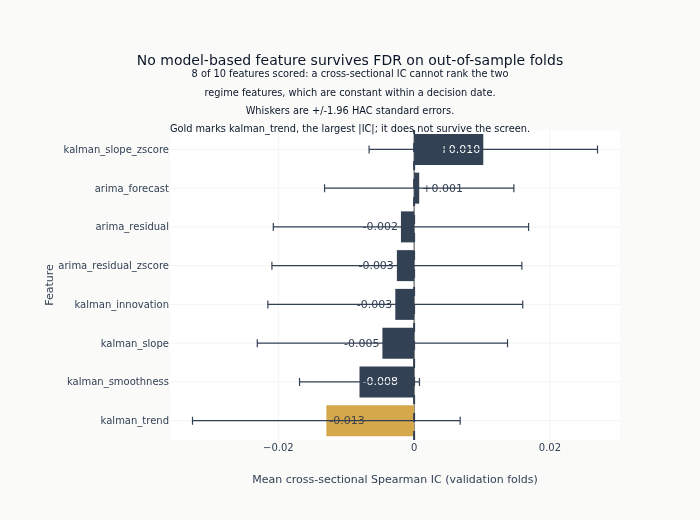

In [35]:
if len(eval_summary):
    fig = go.Figure(
        go.Bar(
            x=plot_summary["ic_mean"],
            y=plot_summary["feature"],
            orientation="h",
            marker_color=bar_colors,
            # Without the interval a bar three times the width of another reads as
            # three times the evidence.
            error_x={
                "type": "data",
                "array": (1.96 * plot_summary["hac_se"]).to_list(),
                "color": COLORS["neutral"],
                "thickness": 1.2,
                "width": 4,
            },
            text=[f"{value:+.3f}" for value in plot_summary["ic_mean"]],
            # `auto`, not `inside`: a bar near zero is narrower than its own label,
            # and forcing the label inside squeezes it to an unreadable column.
            textposition="auto",
            insidetextanchor="end",
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.update_layout(
        title=ic_title,
        xaxis_title="Mean cross-sectional Spearman IC (validation folds)",
        yaxis_title="Feature",
        margin={"l": 170, "t": 130},
        height=520,
    )
    fig.show()
else:
    print(f"Validation IC chart omitted: no date reaches {MIN_PAIRS_PER_DATE} pairs.")

## 9. High-Volatility Regime Diagnostic

The HMM output is a market-level conditioning variable, not a cross-sectional
signal. This validation-only view shows the filtered probability assigned to
the higher-variance state without interpreting that state as risk-off.

Validation windows are contiguous, so the folds concatenate into an unbroken line,
and each segment of that line comes from a separate fit on its own fold's training
window. The dotted rules mark where one fold's model hands over to the next, which
is where a discontinuity would be fit instability rather than a regime change.

Validation sessions with filtered P(high-vol) >= 0.5: 34.7% of 2,063


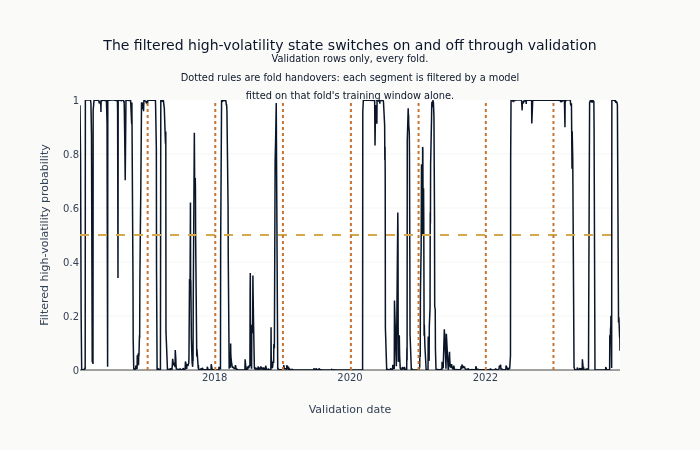

In [36]:
if "hmm_regime_prob_high_vol" in eval_features.columns:
    hmm_validation = (
        eval_features.select("timestamp", "hmm_regime_prob_high_vol")
        .unique("timestamp", keep="last")
        .sort("timestamp")
        .drop_nulls()
    )
    high_vol_share = float((hmm_validation["hmm_regime_prob_high_vol"] >= 0.5).mean())
    print(
        f"Validation sessions with filtered P(high-vol) >= 0.5: {high_vol_share:.1%} "
        f"of {len(hmm_validation):,}"
    )
    fig = go.Figure(
        go.Scatter(
            x=hmm_validation["timestamp"],
            y=hmm_validation["hmm_regime_prob_high_vol"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 1.5},
            showlegend=False,
        )
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["amber"])
    for fold in folds[:-1]:
        fig.add_vline(x=fold["val_start"].isoformat(), line_dash="dot", line_color=COLORS["copper"])
    fig.update_layout(
        title=(
            "The filtered high-volatility state switches on and off through validation"
            "<br><sup>Validation rows only, every fold."
            "<br>Dotted rules are fold handovers: each segment is filtered by a model"
            "<br>fitted on that fold's training window alone.</sup>"
        ),
        xaxis_title="Validation date",
        yaxis_title="Filtered high-volatility probability",
        yaxis_range=[0, 1],
        height=450,
    )
    fig.show()
else:
    high_vol_share = float("nan")
    print("HMM diagnostic omitted: the reduced run produces no USD factor series.")

## Key Takeaways

Kalman, HMM, and ARIMA parameters are estimated inside the exact canonical
training folds. Fixed parameters then filter forward through validation; the
one-session label buffer updates model state without entering either split.
The HMM variables condition the full cross-section, while the remaining
features receive an exploratory FDR-controlled validation screen.

**Known limitations**

- Each model is re-estimated once per fold and then held fixed for the validation
  year that follows, so a structural break inside a validation window is filtered
  with parameters estimated before it.
- The HMM is fitted on one market-level series, so its two columns take the same
  value for every pair on a date and carry no cross-sectional information.
- The ARIMA order is fixed at $(1,0,1)$ for every pair and fold rather than selected
  per pair, so the residual is a surprise relative to one assumed dynamic.
- The screen in section 8 measures each feature on its own. What the set adds
  jointly, and what it adds over the Chapter 8 features, is `05_evaluation`.

**What the artifact contains, and what the validation screen retained.**

In [37]:
print(f"Model-based features written: {len(temporal_feature_cols)}")
print(f"Canonical folds:              {len(folds)}")
if len(eval_summary):
    top_result = eval_summary.row(0, named=True)
    print(f"Features with cross-sectional variation: {len(feature_names)}")
    print(f"Surviving BH-FDR at 5%:                  {n_fdr_sig}")
    print(
        f"Largest absolute validation estimate:    {top_result['feature']} "
        f"(IC {top_result['ic_mean']:+.4f}, HAC t {top_result['hac_tstat']:+.2f})"
    )
else:
    print(
        f"Validation IC omitted: a daily cross-sectional IC needs {MIN_PAIRS_PER_DATE} "
        "pairs on a date and no date in this run reaches that."
    )

Model-based features written: 10
Canonical folds:              8
Features with cross-sectional variation: 8
Surviving BH-FDR at 5%:                  0
Largest absolute validation estimate:    kalman_trend (IC -0.0129, HAC t -1.29)


**Next**: [`05_evaluation.py`](05_evaluation.ipynb) combines these fold-aware
temporal features with the signed Chapter 8 financial features.